# Experiment 3: Necessity Test - Silencing Experiment

**Purpose**
- Reproduce Shiu et al. (2024) Figure 1f-h
- Test which neurons are required for MN9 activation
- Method: Activate 21 Sugar GRNs continuously, silence neurons individually

**Configuration**
- Base activation: 21 Sugar GRNs (left hemisphere)
- Neurons to silence: Top 200 responsive neurons (from Exp1)
- Frequencies: 50, 60, 70, 80, 90, 100, 110, 120 Hz (8 frequencies)
- Trials: 10 per condition
- Batches: 8 batches (1 frequency each, 200 neurons)
- Workers: 4 (optimized from testing)

**Expected Runtime**
- Per batch: 200 neurons ÷ 4 workers × 130s ≈ **90-100 minutes**
- Total: 8 batches × 95 min ≈ **12-13 hours** (can run overnight or over 2 days)

**Memory Requirements**
- Peak: ~9GB (safe for 16GB system)
- Swap: 0GB (verified in mini test)

**Outputs**
- `results/exp3_necessity_test/exp3_complete_results.pkl`
- `results/exp3_necessity_test/necessary_neurons.npy` (for Venn diagram)
- `results/exp3_necessity_test/figures/` (heatmap, histogram, venn)

**Dependencies**
- Requires: `results/exp1_sugar_activation/top_200_neurons.npy`
- Optional: `results/exp2_sufficiency_test/sufficient_neurons.npy` (for Venn)

---

## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from time import time
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from brian2 import Hz, ms, start_scope

from joblib import Parallel, delayed
import gc

print("✅ Standard libraries imported")

✅ Standard libraries imported


In [2]:
# FlyWire tools
from caveclient import CAVEclient

print("Initializing CAVEclient...")
client = CAVEclient('flywire_fafb_public')
print("✅ Connected to FlyWire")

Initializing CAVEclient...
✅ Connected to FlyWire


In [3]:
# FlyLIF modules
from flylif.core.parameters import DEFAULT_PARAMS
from flylif.core.data_loader import load_simulation_data
from flylif.core.experiments import run_exp3_parallel
from flylif.utils.cave_utils import convert_neuron_list_cached
from flylif.utils.checkpoint import CheckpointManager
from flylif.utils.memory_utils import print_memory, check_memory_safe, memory_cleanup, MemoryMonitor

print("✅ FlyLIF modules imported")

✅ FlyLIF modules imported


In [4]:
# Auto-reload
%load_ext autoreload
%autoreload 2
print("✅ Auto-reload enabled")

✅ Auto-reload enabled


## 2. Configuration

In [5]:
# ===== Configuration =====
PROJECT_ROOT = Path.cwd()  # exp3 notebook in root

CONFIG = {
    'data_dir': PROJECT_ROOT / 'data_783',
    'connections_file': 'proofread_connections_783.feather',
    'root_ids_file': 'proofread_root_ids_783.npy',
}

# Exp3 directories
CACHE_DIR = PROJECT_ROOT / 'cache' / 'id_conversions'
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints' / 'exp3_full'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'exp3_necessity_test'
FIGURES_DIR = RESULTS_DIR / 'figures'
CONTROLS_DIR = RESULTS_DIR / 'controls'  # For baseline firing rates

# Dependencies
EXP1_RESULTS = PROJECT_ROOT / 'results' / 'exp1_sugar_activation'
EXP2_RESULTS = PROJECT_ROOT / 'results' / 'exp2_sufficiency_test'  # For Venn diagram

# Create directories
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CONTROLS_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Project root: {PROJECT_ROOT}")
print(f"  Data: {CONFIG['data_dir']}")
print(f"  Results: {RESULTS_DIR}")
print(f"  Checkpoint: {CHECKPOINT_DIR}")

Configuration:
  Project root: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation
  Data: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/data_783
  Results: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/results/exp3_necessity_test
  Checkpoint: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/checkpoints/exp3_full


## 3. Pre-Experiment Checks 

### 3.1 Brian2 cache

In [ ]:
import shutil
cache_dir = Path.home() / 'Library/Caches/cython/brian_extensions'

print("Completely removing Brian2 cache...")
shutil.rmtree(cache_dir)
cache_dir.mkdir(parents=True, exist_ok=True)
print("✅ Fresh start!")

# 验证
locks_after = list(cache_dir.glob('*.lock'))
print(f"Lock count after clean: {len(locks_after)} (should be 0)")

### 3.2 Memory status

In [ ]:
print("\nPre-experiment memory status:")
is_safe, msg = check_memory_safe(threshold=75.0, swap_threshold=0.5)
print(f"  {msg}")

if not is_safe:
    print("\n⚠️  High memory detected!")
    print("   Recommend: Kernel → Restart Kernel")
    print("   Then re-run Cells 1-7")
else:
    print("\n✅ Memory OK, ready to start")

## 4. Load Data & Dependencies 

In [6]:
# ===== Load Essential Data & Dependencies =====

def load_essentials_exp3():
    """
    Load connectivity data, neuron IDs, and experiment dependencies.
    
    Dependencies:
    - Exp1: top_200_neurons.npy (required)
    - Exp2: sufficient_neurons.npy (optional, for Venn diagram)
    
    All neuron ID conversions use cached results from Exp1.
    """
    global DATA, NEU_SUGAR_LEFT, NEU_MN9_RIGHT, NEU_MN9_LEFT, top_200_neurons, sufficient_neurons
    
    print("\n" + "=" * 70)
    print("Loading Data & Dependencies")
    print("=" * 70)
    
    # ─────────────────────────────────────────────────────────────
    # 1. Connectivity Data
    # ─────────────────────────────────────────────────────────────
    if 'DATA' not in globals():
        print("\n[1/4] Loading connectivity data...")
        t0 = time()
        DATA = load_simulation_data(CONFIG, verbose=False)
        print(f"  ✅ {DATA['n_neurons']:,} neurons, {len(DATA['df_conn']):,} connections")
        print(f"     ({DATA['df_conn'].memory_usage(deep=True).sum()/1e6:.0f} MB, {time()-t0:.1f}s)")
    else:
        print(f"\n[1/4] ✓ Using cached DATA ({DATA['n_neurons']:,} neurons)")
    
    # ─────────────────────────────────────────────────────────────
    # 2. Neuron IDs (from Exp1 cache)
    # ─────────────────────────────────────────────────────────────
    if 'NEU_SUGAR_LEFT' not in globals() or 'NEU_MN9_RIGHT' not in globals():
        print("\n[2/4] Loading neuron IDs (from cache)...")
        
        # Original v630 IDs
        NEU_SUGAR_v630 = [
            720575940624963786, 720575940630233916, 720575940637568838, 
            720575940638202345, 720575940617000768, 720575940630797113, 
            720575940632889389, 720575940621754367, 720575940621502051, 
            720575940640649691, 720575940639332736, 720575940616885538, 
            720575940639198653, 720575940620900446, 720575940617937543,
            720575940632425919, 720575940633143833, 720575940612670570, 
            720575940628853239, 720575940629176663, 720575940611875570
        ]
        NEU_MN9_v630 = [720575940660219265]
        NEU_MN9_LEFT_v630 = [720575940645521262]
        
        # Load from cache (converted in Exp1)
        NEU_SUGAR_LEFT = convert_neuron_list_cached(
            old_list=NEU_SUGAR_v630,
            cache_file=CACHE_DIR / 'sugar_grns_v630_to_v783.pkl',
            new_ver=783, verbose=False
        )
        NEU_MN9_RIGHT = convert_neuron_list_cached(
            old_list=NEU_MN9_v630,
            cache_file=CACHE_DIR / 'mn9_v630_to_v783.pkl',
            new_ver=783, verbose=False
        )
        NEU_MN9_LEFT = convert_neuron_list_cached(
            old_list=NEU_MN9_LEFT_v630,
            cache_file=CACHE_DIR / 'mn9_left_v630_to_v783.pkl',
            new_ver=783, verbose=False
        )
        
        print(f"  ✅ Sugar GRNs: {len(NEU_SUGAR_LEFT)} neurons")
        print(f"  ✅ MN9 Right: {NEU_MN9_RIGHT[0]}")
        print(f"  ✅ MN9 Left: {NEU_MN9_LEFT[0]}")
    else:
        print(f"\n[2/4] ✓ Using cached neuron IDs")
    
    # ─────────────────────────────────────────────────────────────
    # 3. Exp1 Results (required)
    # ─────────────────────────────────────────────────────────────
    if 'top_200_neurons' not in globals():
        print("\n[3/4] Loading Exp1 results...")
        
        exp1_file = EXP1_RESULTS / 'top_200_neurons.npy'
        
        if not exp1_file.exists():
            raise FileNotFoundError(
                f"\n❌ Exp1 results not found!\n"
                f"   Expected: {exp1_file}\n"
                f"   Please run exp1_sugar_activation.ipynb first!"
            )
        
        top_200_neurons = list(np.load(exp1_file))
        print(f"  ✅ Top 200 neurons: {len(top_200_neurons)}")
    else:
        print(f"\n[3/4] ✓ Using cached top_200_neurons ({len(top_200_neurons)})")
    
    # ─────────────────────────────────────────────────────────────
    # 4. Exp2 Results (optional, for Venn diagram)
    # ─────────────────────────────────────────────────────────────
    if 'sufficient_neurons' not in globals():
        print("\n[4/4] Loading Exp2 results (optional)...")
        
        exp2_file = EXP2_RESULTS / 'sufficient_neurons.npy'
        
        if exp2_file.exists():
            sufficient_neurons = set(np.load(exp2_file))
            print(f"  ✅ Sufficient neurons: {len(sufficient_neurons)}")
            print(f"     (Enables Sufficiency vs Necessity Venn diagram)")
        else:
            sufficient_neurons = None
            print(f"  ⚠️  Exp2 results not found (optional)")
            print(f"     Venn diagram will be skipped")
    else:
        print(f"\n[4/4] ✓ Using cached sufficient_neurons")
    
    print("\n" + "=" * 70)
    print("✅ All dependencies loaded")
    print("=" * 70)

# Execute
load_essentials_exp3()


Loading Data & Dependencies

[1/4] Loading connectivity data...
  ✅ 139,255 neurons, 2,710,038 connections
     (68 MB, 26.6s)

[2/4] Loading neuron IDs (from cache)...
  ✅ Sugar GRNs: 21 neurons
  ✅ MN9 Right: 720575940660219265
  ✅ MN9 Left: 720575940618238523

[3/4] Loading Exp1 results...
  ✅ Top 200 neurons: 200

[4/4] Loading Exp2 results (optional)...
  ✅ Sufficient neurons: 61
     (Enables Sufficiency vs Necessity Venn diagram)

✅ All dependencies loaded


## 5. Experiment Configuration

In [7]:
# ========== EXPERIMENT PARAMETERS ==========

# Frequencies (matching original paper Fig 1f)
FREQ_LIST_FULL = [50, 60, 70, 80, 90, 100, 110, 120]

# Batch configuration (by frequency)
BATCH_CONFIG = {
    'batch1': [50],   # 200 neurons × 1 freq
    'batch2': [60],
    'batch3': [70],
    'batch4': [80],
    'batch5': [90],
    'batch6': [100],
    'batch7': [110],
    'batch8': [120],
}

N_TRIALS = 10
N_WORKERS = 4  # Optimized from mini test


print("=" * 70)
print("Experiment 3: Necessity Test Configuration")
print("=" * 70)
print(f"\n[Configuration]")
print(f"  Neurons to silence: {len(top_200_neurons)}")
print(f"  Frequencies: {FREQ_LIST_FULL}")
print(f"  Trials per condition: {N_TRIALS}")
print(f"  Workers: {N_WORKERS}")
print(f"  Checkpoint: {CHECKPOINT_DIR}")

print(f"\\n[Batch Strategy]")
print(f"  Total batches: {len(BATCH_CONFIG)}")
print(f"  Tasks per batch: {len(top_200_neurons)} neurons × 1 freq = 200")
print(f"  Time per batch: ~90-100 minutes")

print(f"\\n[Total Workload]")
total_tasks = len(top_200_neurons) * len(FREQ_LIST_FULL)
print(f"  Total simulations: {total_tasks}")
print(f"  Estimated time: ~12-13 hours")

print("\n" + "=" * 70)

Experiment 3: Necessity Test Configuration

[Configuration]
  Neurons to silence: 200
  Frequencies: [50, 60, 70, 80, 90, 100, 110, 120]
  Trials per condition: 10
  Workers: 4
  Checkpoint: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/checkpoints/exp3_full
\n[Batch Strategy]
  Total batches: 8
  Tasks per batch: 200 neurons × 1 freq = 200
  Time per batch: ~90-100 minutes
\n[Total Workload]
  Total simulations: 1600
  Estimated time: ~12-13 hours



## 6. Execute Batches

**Instructions**:
- Run each batch cell separately
- Each batch takes ~25-30 minutes
- Can restart kernel between batches if needed
- Checkpoint auto-saves progress (safe to interrupt)

**Strategy**:
- Option A: Run all 8 batches overnight (3.7 hours)
- Option B: Run 2-3 batches at a time, spread over 2-3 days

### 6.1 Batch 1: 50 Hz

In [8]:
print("\n" + "=" * 70)
print("Batch 1: Frequency 50 Hz")
print("=" * 70)

# ─────────────────────────────────────────────────────────────
# Check if control already exists
# ─────────────────────────────────────────────────────────────
control_file = CONTROLS_DIR / 'control_50.pkl'

if control_file.exists():
    with open(control_file, 'rb') as f:
        control_50 = pickle.load(f)
    precomputed_controls = {50: control_50}
    print(f"✓ Using saved control: {control_50['mean']:.1f}±{control_50['std']:.1f} Hz")
else:
    precomputed_controls = None
    print(f"Control will be computed (first run)")

# ─────────────────────────────────────────────────────────────
# Run batch
# ─────────────────────────────────────────────────────────────
with MemoryMonitor(label="Batch1_50Hz", warn_threshold=80.0):
    t0 = time()
    
    results_batch1 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[50],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=precomputed_controls,  
        verbose=False
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 1 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

# ─────────────────────────────────────────────────────────────
# Save control (if newly computed)
# ─────────────────────────────────────────────────────────────
if precomputed_controls is None:
    control_50 = results_batch1[50]['control']
    with open(control_file, 'wb') as f:
        pickle.dump(control_50, f)
    print(f"\n💾 Saved control: {control_file.name}")
    print(f"   {control_50['mean']:.1f} ± {control_50['std']:.1f} Hz")
else:
    print(f"\n✓ Control loaded from cache (not re-saved)")


Batch 1: Frequency 50 Hz
✓ Using saved control: 18.8±8.3 Hz
[Batch1_50Hz] Start - Memory: 49.5%
[Batch1_50Hz] End - Memory: 49.6% (Δ+0.0GB)

✅ Batch 1 complete! Time: 0.0 min
Final: Memory: 49.6% used, 8.7GB free, Swap: 1.2GB

✓ Control loaded from cache (not re-saved)


### 6.2 Batch 2: 60 Hz

In [ ]:
# ─────────────────────────────────────────────────────────────
# Batch 2: Frequency 60 Hz
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Batch 2: Frequency 60 Hz")
print("=" * 70)

control_file = CONTROLS_DIR / 'control_60.pkl'

if control_file.exists():
    with open(control_file, 'rb') as f:
        control_60 = pickle.load(f)
    precomputed_controls = {60: control_60}
    print(f"✓ Using saved control: {control_60['mean']:.1f}±{control_60['std']:.1f} Hz")
else:
    precomputed_controls = None
    print(f"Control will be computed (first run)")

with MemoryMonitor(label="Batch2_60Hz", warn_threshold=80.0):
    t0 = time()
    results_batch2 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[60],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=precomputed_controls,
        verbose=False
    )
    elapsed = time() - t0

print(f"\n✅ Batch 2 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

if precomputed_controls is None:
    control_60 = results_batch2[60]['control']
    with open(control_file, 'wb') as f:
        pickle.dump(control_60, f)
    print(f"\n💾 Saved control: {control_file.name}")

### 6.3 Batch 3: 70 Hz

In [10]:
# ─────────────────────────────────────────────────────────────
# Batch 3: Frequency 70 Hz
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Batch 3: Frequency 70 Hz")
print("=" * 70)

control_file = CONTROLS_DIR / 'control_70.pkl'

if control_file.exists():
    with open(control_file, 'rb') as f:
        control_70 = pickle.load(f)
    precomputed_controls = {70: control_70}
    print(f"✓ Using saved control: {control_70['mean']:.1f}±{control_70['std']:.1f} Hz")
else:
    precomputed_controls = None
    print(f"Control will be computed (first run)")

with MemoryMonitor(label="Batch3_70Hz", warn_threshold=80.0):
    t0 = time()
    results_batch3 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[70],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=precomputed_controls,
        verbose=False
    )
    elapsed = time() - t0

print(f"\n✅ Batch 3 complete! Time: {elapsed/60:.1f} min")
if precomputed_controls is None:
    control_70 = results_batch3[70]['control']
    with open(control_file, 'wb') as f:
        pickle.dump(control_70, f)


Batch 3: Frequency 70 Hz
✓ Using saved control: 66.7±5.2 Hz
[Batch3_70Hz] Start - Memory: 49.8%
[Batch3_70Hz] End - Memory: 49.8% (Δ+0.0GB)

✅ Batch 3 complete! Time: 0.0 min


### 6.4 Batch 4: 80 Hz

In [ ]:
print("\n" + "=" * 70)
print("Batch 4: Frequency 80 Hz")
print("=" * 70)

control_file = CONTROLS_DIR / 'control_80.pkl'

if control_file.exists():
    with open(control_file, 'rb') as f:
        control_80 = pickle.load(f)
    precomputed_controls = {80: control_80}
    print(f"✓ Using saved control: {control_80['mean']:.1f}±{control_80['std']:.1f} Hz")
else:
    precomputed_controls = None
    print(f"Control will be computed (first run)")

with MemoryMonitor(label="Batch4_80Hz", warn_threshold=80.0):
    t0 = time()
    results_batch4 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[80],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=precomputed_controls,
        verbose=False
    )
    elapsed = time() - t0

print(f"\n✅ Batch 4 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

if precomputed_controls is None:
    control_80 = results_batch4[80]['control']
    with open(control_file, 'wb') as f:
        pickle.dump(control_80, f)
    print(f"\n💾 Saved control: {control_file.name}")

### 6.5 Batch 5: 90 Hz

In [ ]:
print("\n" + "=" * 70)
print("Batch 5: Frequency 90 Hz")
print("=" * 70)

control_file = CONTROLS_DIR / 'control_90.pkl'

if control_file.exists():
    with open(control_file, 'rb') as f:
        control_90 = pickle.load(f)
    precomputed_controls = {90: control_90}
    print(f"✓ Using saved control: {control_90['mean']:.1f}±{control_90['std']:.1f} Hz")
else:
    precomputed_controls = None
    print(f"Control will be computed (first run)")

with MemoryMonitor(label="Batch5_90Hz", warn_threshold=80.0):
    t0 = time()
    results_batch5 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[90],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=precomputed_controls,
        verbose=False
    )
    elapsed = time() - t0

print(f"\n✅ Batch 5 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

if precomputed_controls is None:
    control_90 = results_batch5[90]['control']
    with open(control_file, 'wb') as f:
        pickle.dump(control_90, f)
    print(f"\n💾 Saved control: {control_file.name}")

### 6.6 Batch 6: 100 Hz

In [ ]:
print("\n" + "=" * 70)
print("Batch 6: Frequency 100 Hz")
print("=" * 70)

control_file = CONTROLS_DIR / 'control_100.pkl'

if control_file.exists():
    with open(control_file, 'rb') as f:
        control_100 = pickle.load(f)
    precomputed_controls = {100: control_100}
    print(f"✓ Using saved control: {control_100['mean']:.1f}±{control_100['std']:.1f} Hz")
else:
    precomputed_controls = None
    print(f"Control will be computed (first run)")

with MemoryMonitor(label="Batch6_100Hz", warn_threshold=80.0):
    t0 = time()
    results_batch6 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[100],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=precomputed_controls,
        verbose=False
    )
    elapsed = time() - t0

print(f"\n✅ Batch 6 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

if precomputed_controls is None:
    control_100 = results_batch6[100]['control']
    with open(control_file, 'wb') as f:
        pickle.dump(control_100, f)
    print(f"\n💾 Saved control: {control_file.name}")

### 6.7 Batch 7: 110 Hz

In [ ]:
print("\n" + "=" * 70)
print("Batch 7: Frequency 110 Hz")
print("=" * 70)

control_file = CONTROLS_DIR / 'control_110.pkl'

if control_file.exists():
    with open(control_file, 'rb') as f:
        control_110 = pickle.load(f)
    precomputed_controls = {110: control_110}
    print(f"✓ Using saved control: {control_110['mean']:.1f}±{control_110['std']:.1f} Hz")
else:
    precomputed_controls = None
    print(f"Control will be computed (first run)")

with MemoryMonitor(label="Batch7_110Hz", warn_threshold=80.0):
    t0 = time()
    results_batch7 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[110],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=precomputed_controls,
        verbose=False
    )
    elapsed = time() - t0

print(f"\n✅ Batch 7 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

if precomputed_controls is None:
    control_110 = results_batch7[110]['control']
    with open(control_file, 'wb') as f:
        pickle.dump(control_110, f)
    print(f"\n💾 Saved control: {control_file.name}")

### 6.8 Batch 8: 120 Hz (Final)

In [ ]:
print("\n" + "=" * 70)
print("Batch 8: Frequency 120 Hz")
print("=" * 70)

control_file = CONTROLS_DIR / 'control_120.pkl'

if control_file.exists():
    with open(control_file, 'rb') as f:
        control_120 = pickle.load(f)
    precomputed_controls = {120: control_120}
    print(f"✓ Using saved control: {control_120['mean']:.1f}±{control_120['std']:.1f} Hz")
else:
    precomputed_controls = None
    print(f"Control will be computed (first run)")

with MemoryMonitor(label="Batch8_120Hz", warn_threshold=80.0):
    t0 = time()
    results_batch8 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[120],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=precomputed_controls,
        verbose=False
    )
    elapsed = time() - t0

print(f"\n✅ Batch 8 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

if precomputed_controls is None:
    control_120 = results_batch8[120]['control']
    with open(control_file, 'wb') as f:
        pickle.dump(control_120, f)
    print(f"\n💾 Saved control: {control_file.name}")

## 7. Process Results & Analysis  

#### 7.1 Merge silencing results

In [8]:
print("\n" + "="*70)
print("Merging All Batch Results")
print("="*70)

# Step 1: Load all controls from saved files
print("\n[1/2] Loading saved controls...")

all_controls = {}
missing_controls = []

for freq in FREQ_LIST_FULL:
    control_file = CONTROLS_DIR / f'control_{freq}.pkl'
    
    if control_file.exists():
        with open(control_file, 'rb') as f:
            all_controls[freq] = pickle.load(f)
        print(f"  ✅ {freq} Hz: {all_controls[freq]['mean']:.1f}±{all_controls[freq]['std']:.1f}")
    else:
        missing_controls.append(freq)
        print(f"  ❌ {freq} Hz: Not found")

if missing_controls:
    raise FileNotFoundError(
        f"Missing controls for frequencies: {missing_controls}\\n"
        f"Please complete all batches first!"
    )

# Step 2: Load all silencing results from checkpoint
print(f"\n[2/2] Loading silencing results from checkpoint...")

ckpt = CheckpointManager(CHECKPOINT_DIR)
all_completed = ckpt.load_all_completed()

print(f"  Total tasks in checkpoint: {len(all_completed)}")

# Organize into results structure
results_exp3_full = {}

for freq in FREQ_LIST_FULL:
    results_exp3_full[freq] = {
        'control': all_controls[freq],
        'silencing': {}
    }

# Fill in silencing results
for task_key, data in all_completed.items():
    nid = data['neuron_id']
    freq = data['freq']
    stats = data['stats']
    
    if freq in results_exp3_full:
        results_exp3_full[freq]['silencing'][nid] = stats

# Verify completeness
print(f"\n[Verification]")
all_complete = True
for freq in FREQ_LIST_FULL:
    n_silencing = len(results_exp3_full[freq]['silencing'])
    
    status = "✅" if n_silencing == 200 else "❌"
    print(f"  {status} {freq} Hz: Control ✅, Silencing {n_silencing}/200")
    
    if n_silencing != 200:
        all_complete = False

if all_complete:
    print(f"\n✅ All frequencies complete! Ready for analysis.")
else:
    print(f"\n⚠️  Some batches incomplete, continue running missing batches")

print("=" * 70)


Merging All Batch Results

[1/2] Loading saved controls...
  ✅ 50 Hz: 18.8±8.3
  ✅ 60 Hz: 47.6±9.2
  ✅ 70 Hz: 66.7±5.2
  ✅ 80 Hz: 77.8±9.1
  ✅ 90 Hz: 82.3±4.4
  ✅ 100 Hz: 90.5±4.7
  ✅ 110 Hz: 91.9±4.2
  ✅ 120 Hz: 95.1±5.3

[2/2] Loading silencing results from checkpoint...
  Total tasks in checkpoint: 1600

[Verification]
  ✅ 50 Hz: Control ✅, Silencing 200/200
  ✅ 60 Hz: Control ✅, Silencing 200/200
  ✅ 70 Hz: Control ✅, Silencing 200/200
  ✅ 80 Hz: Control ✅, Silencing 200/200
  ✅ 90 Hz: Control ✅, Silencing 200/200
  ✅ 100 Hz: Control ✅, Silencing 200/200
  ✅ 110 Hz: Control ✅, Silencing 200/200
  ✅ 120 Hz: Control ✅, Silencing 200/200

✅ All frequencies complete! Ready for analysis.


### 7.2 Analysis: Identify Necessary Neurons

In [9]:
print("\n" + "=" * 70)
print("Analyzing Necessary Neurons")
print("=" * 70)

# Define threshold for "necessary" (silencing reduces MN9 to <80% of control)
NECESSITY_THRESHOLD = 75.0  # %

# For each frequency, identify necessary neurons
necessary_by_freq = {}

# Analysis部分也要排除GRNs
for freq in FREQ_LIST_FULL:
    necessary_neurons = []
    silencing = results_exp3_full[freq]['silencing']
    
    for nid, stats in silencing.items():
        # === 只分析non-GRNs ===
        if nid not in NEU_SUGAR_LEFT and stats['relative_%'] < NECESSITY_THRESHOLD:
            necessary_neurons.append(nid)
    
    necessary_by_freq[freq] = necessary_neurons
    
    print(f"\n{freq} Hz:")
    print(f"  Necessary neurons: {len(necessary_neurons)}/200 ({100*len(necessary_neurons)/200:.1f}%)")
    print(f"  Control MN9: {results_exp3_full[freq]['control']['mean']:.1f} Hz")

# Neurons necessary at ANY frequency
necessary_any = set()
for neurons in necessary_by_freq.values():
    necessary_any.update(neurons)

print(f"\n[Summary]")
print(f"  Neurons necessary at ANY frequency: {len(necessary_any)}")
print(f"  Threshold used: <{NECESSITY_THRESHOLD}% of control")


Analyzing Necessary Neurons

50 Hz:
  Necessary neurons: 19/200 (9.5%)
  Control MN9: 18.8 Hz

60 Hz:
  Necessary neurons: 7/200 (3.5%)
  Control MN9: 47.6 Hz

70 Hz:
  Necessary neurons: 4/200 (2.0%)
  Control MN9: 66.7 Hz

80 Hz:
  Necessary neurons: 2/200 (1.0%)
  Control MN9: 77.8 Hz

90 Hz:
  Necessary neurons: 2/200 (1.0%)
  Control MN9: 82.3 Hz

100 Hz:
  Necessary neurons: 2/200 (1.0%)
  Control MN9: 90.5 Hz

110 Hz:
  Necessary neurons: 2/200 (1.0%)
  Control MN9: 91.9 Hz

120 Hz:
  Necessary neurons: 2/200 (1.0%)
  Control MN9: 95.1 Hz

[Summary]
  Neurons necessary at ANY frequency: 19
  Threshold used: <75.0% of control


## 8. Visualization

### 8.1 Silencing heatmap (Figure 1f style)


Figure 1: Silencing effects heatmap


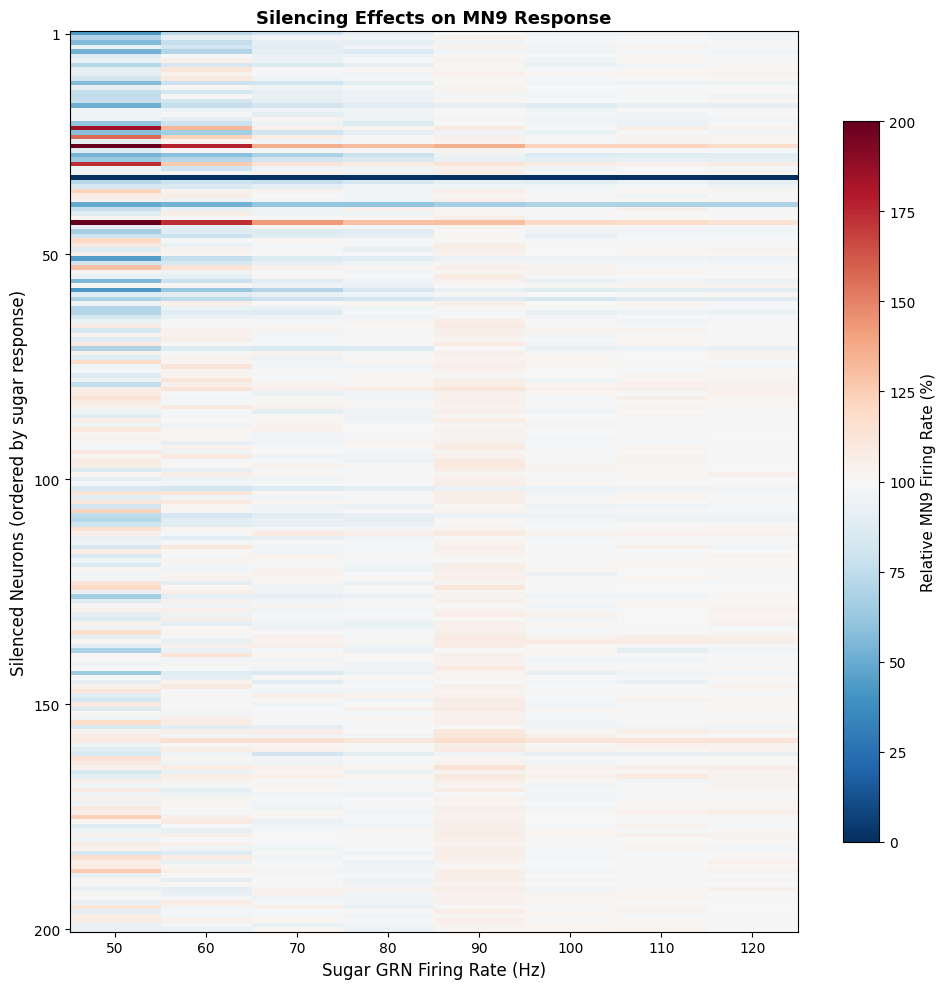

  ✅ Saved: fig1_silencing_heatmap.png


In [217]:
print("\nFigure 1: Silencing effects heatmap")

# Prepare data for heatmap
from flylif.utils.visualization import plot_response_heatmap
import matplotlib.colors as mcolors

# Convert to format compatible with plot_response_heatmap
# (relative % instead of absolute firing rates)
relative_rates_matrix = {}
for freq in FREQ_LIST_FULL:
    relative_rates_matrix[freq] = {
        nid: stats['relative_%'] 
        for nid, stats in results_exp3_full[freq]['silencing'].items()
    }

# Plot using custom heatmap
fig, ax = plt.subplots(figsize=(10, 10))

# Build matrix (neurons × frequencies)
matrix = np.zeros((len(top_200_neurons), len(FREQ_LIST_FULL)))
for j, freq in enumerate(FREQ_LIST_FULL):
    for i, nid in enumerate(top_200_neurons):
        if nid in relative_rates_matrix[freq]:
            val = relative_rates_matrix[freq][nid]
            matrix[i, j] = val if val != np.inf else 200

# Use diverging colormap centered at 100%
cmap = plt.cm.RdBu_r
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=100, vmax=200)

im = ax.imshow(matrix, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('Silenced Neurons (ordered by sugar response)', fontsize=12)
ax.set_title('Silencing Effects on MN9 Response', fontsize=13, fontweight='bold')

# X ticks
ax.set_xticks(range(len(FREQ_LIST_FULL)))
ax.set_xticklabels(FREQ_LIST_FULL)

# Y ticks
n_yticks = 5
y_positions = np.linspace(0, len(top_200_neurons)-1, n_yticks).astype(int)
ax.set_yticks(y_positions)
ax.set_yticklabels([f'{i+1}' for i in y_positions])

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Relative MN9 Firing Rate (%)', fontsize=11)
# cbar.ax.axhline(y=0.5, color='black', linewidth=1.5, linestyle='-')  # 100% line
# cbar.ax.axhline(y=0.4, color='orange', linewidth=1, linestyle='--')  # 80% line

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_silencing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: fig1_silencing_heatmap.png")

### 8.2 Silencing effect histogram (Figure 1g style)


Figure 2: Silencing effect distribution (at 50 Hz, non-GRNs)

Filtering:
  Total tested: 200 neurons
  Sugar GRNs: 21
  Non-GRNs: 179


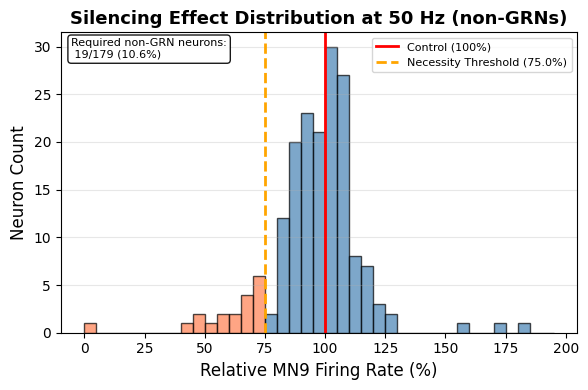

  ✅ Saved: fig2_silencing_histogram_50Hz_nonGRNs.png
  Required non-GRN neurons at 50Hz: 19/179


In [17]:
# ========== 10.2 Silencing effect histogram (Figure 1g style) ==========

print("\nFigure 2: Silencing effect distribution (at 50 Hz, non-GRNs)")

# Use 50 Hz as example (lowest frequency)
freq_plot = 50
silencing_50 = results_exp3_full[freq_plot]['silencing']

# === Filter out Sugar GRNs ===
non_grn_neurons = [nid for nid in silencing_50.keys() 
                   if nid not in NEU_SUGAR_LEFT]  # ← 排除GRNs

print(f"\nFiltering:")
print(f"  Total tested: {len(silencing_50)} neurons")
print(f"  Sugar GRNs: {len(NEU_SUGAR_LEFT)}")
print(f"  Non-GRNs: {len(non_grn_neurons)}")

# Extract relative rates (non-GRNs only)
relative_rates = []
for nid in non_grn_neurons:
    rate = silencing_50[nid]['relative_%']
    if rate != np.inf and rate < 500:  # Filter outliers
        relative_rates.append(rate)

# Plot histogram
fig, ax = plt.subplots(figsize=(6, 4))

bins = np.arange(0, 200, 5)
counts, edges, patches = ax.hist(relative_rates, bins=bins, 
                                  edgecolor='black', alpha=0.7, color='steelblue')

# Color bars below threshold
for i, (count, patch) in enumerate(zip(counts, patches)):
    if edges[i] < NECESSITY_THRESHOLD:
        patch.set_facecolor('coral')

# Reference lines
ax.axvline(x=100, color='red', linestyle='-', linewidth=2, label='Control (100%)')
ax.axvline(x=NECESSITY_THRESHOLD, color='orange', linestyle='--', linewidth=2, 
           label=f'Necessity Threshold ({NECESSITY_THRESHOLD}%)')

ax.set_xlabel('Relative MN9 Firing Rate (%)', fontsize=12)
ax.set_ylabel('Neuron Count', fontsize=12)
ax.set_title(f'Silencing Effect Distribution at {freq_plot} Hz (non-GRNs)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Statistics text (non-GRNs only)
n_required = sum(1 for r in relative_rates if r < NECESSITY_THRESHOLD)
n_total = len(relative_rates)
textstr = f'Required non-GRN neurons:\n {n_required}/{n_total} ({100*n_required/n_total:.1f}%)'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_silencing_histogram_50Hz_nonGRNs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: fig2_silencing_histogram_50Hz_nonGRNs.png")
print(f"  Required non-GRN neurons at 50Hz: {n_required}/{n_total}")

### 8.3 Venn diagram: Sufficiency vs Necessity (Figure 1h style)


Figure 3: Sufficiency vs Necessity Venn diagram

Checking Exp2 results:
  Path: /Users/ruiluo/MyLibrary/connectome/LIFmodel/LIF_simulation/results/exp2_sufficiency_test/exp2_complete_results.pkl
  Exists: True
  ✅ Loading Exp2 results...

  Sets defined:
    Sufficient (activate MN9): 54 neurons
    Necessary (required for MN9): 18 non-GRN neurons


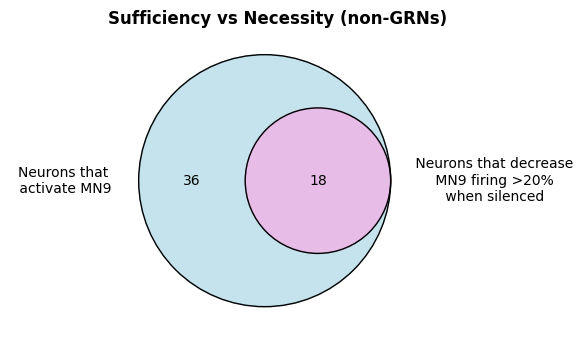


  ✅ Saved: fig3_venn_diagram.png
  Overlap: 18 neurons
  Only sufficient: 36



In [61]:
# ========== 10.3 Venn diagram: Sufficiency vs Necessity (Figure 1h style) ==========

print("\nFigure 3: Sufficiency vs Necessity Venn diagram")

# Try relative path first
exp2_file = exp2_file = EXP2_RESULTS / 'exp2_complete_results.pkl' 

# Verify file exists
print(f"\nChecking Exp2 results:")
print(f"  Path: {exp2_file}")
print(f"  Exists: {exp2_file.exists()}")

if exp2_file.exists():
    print(f"  ✅ Loading Exp2 results...")
    
    with open(exp2_file, 'rb') as f:
        exp2_results = pickle.load(f)
    
    # Get sufficient neurons (activate MN9 at 200 Hz)
    sufficient_neurons = set()
    
    if 'results' in exp2_results:
        # Check if 200Hz data exists
        if 200 in exp2_results['results']:
            for nid, stats in exp2_results['results'][200].items():
                if stats['mean'] > 0 and  nid not in NEU_SUGAR_LEFT and nid not in NEU_MN9_RIGHT:  # Activates MN9
                    sufficient_neurons.add(nid)
        else:
            # Use highest available frequency
            max_freq = max(exp2_results['results'].keys())
            print(f"  ⚠️  Using {max_freq}Hz instead of 200Hz")
            for nid, stats in exp2_results['results'][max_freq].items():
                if stats['mean'] > 0:
                    sufficient_neurons.add(nid)
                
    
    # Get necessary neurons (from current Exp3 at 50 Hz, exclude GRNs)
    necessary_neurons = set()
    silencing_50 = results_exp3_full[50]['silencing']
    
    for nid, stats in silencing_50.items():
        # Exclude Sugar GRNs
        if  nid not in NEU_SUGAR_LEFT and nid not in NEU_MN9_RIGHT and stats['relative_%'] < NECESSITY_THRESHOLD:
            necessary_neurons.add(nid)
        
    print(f"\n  Sets defined:")
    print(f"    Sufficient (activate MN9): {len(sufficient_neurons)} neurons")
    print(f"    Necessary (required for MN9): {len(necessary_neurons)} non-GRN neurons")
    
    # Plot Venn
    try:
        from matplotlib_venn import venn2, venn2_circles
        
        fig, ax = plt.subplots(figsize=(6, 6))
        
        v = venn2([sufficient_neurons, necessary_neurons],
                  set_labels=None,
                  ax=ax )
               
        # Color patches
        if v.get_patch_by_id('10'):
            v.get_patch_by_id('10').set_color('lightblue')
            v.get_patch_by_id('10').set_alpha(0.7)
            
        if v.get_patch_by_id('01'):
            v.get_patch_by_id('01').set_color('lightcoral')
            v.get_patch_by_id('01').set_alpha(0.7)
            
        if v.get_patch_by_id('11'):
            v.get_patch_by_id('11').set_color('plum')
            v.get_patch_by_id('11').set_alpha(0.7)
        
        venn2_circles([sufficient_neurons, necessary_neurons], ax=ax, linewidth=1)
        
        ax.text(0.1, 0.5, f'Neurons that\n activate MN9', 
                transform=ax.transAxes, fontsize=10, 
                ha='center', va='center', color='black')

        ax.text(0.9, 0.5, f' Neurons that decrease\n MN9 firing >20%\n when silenced', 
                transform=ax.transAxes, fontsize=10, 
                ha='center', va='center', color='black')
                              
        overlap = len(sufficient_neurons & necessary_neurons)
        ax.set_title(f'Sufficiency vs Necessity (non-GRNs)', 
                    fontsize=12, fontweight='bold')

        plt.tight_layout()
        ax.set_xlim(-1.2, 1.2) #control cirle size
        ax.axis('off') 

        for label in v.subset_labels:
            if label is not None and label.get_text() == '0':
                label.set_text("")
        plt.savefig(FIGURES_DIR/ 'fig3_venn_diagram.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\n  ✅ Saved: fig3_venn_diagram.png")
        print(f"  Overlap: {overlap} neurons")
        print(f"  Only sufficient: {len(sufficient_neurons - necessary_neurons)}")
               
    except ImportError:
        print(f"\n  ⚠️  matplotlib-venn not installed")
        print(f"     Install: pip install matplotlib-venn")
        print(f"     Skipping Venn diagram")

else:
    print(f"\n  ❌ Exp2 results not found: {exp2_file}")
    print(f"     Run exp2_sufficiency_test.ipynb first!")
    print(f"     Or check if path is correct")

print("\n" + "="*70)

### 8.4 Circuit Connectivity Analysis

In [139]:
rate_sn_neurons = {}
rate_sn_neurons['control'] = all_controls[50]
for neuron in necessary_neurons:
    rate_sn_neurons[neuron] = results_exp3_full[50]['silencing'][neuron]

df_rate_sn_neurons = pd.DataFrame.from_dict(rate_sn_neurons, orient='index')
df_rate_sn_neurons.index.name = 'neuron_id'
# df_rate_sn_neurons.reset_index(inplace=True)
df_rate_sn_neurons = df_rate_sn_neurons.sort_values(by='mean', ascending=False)

# search id to neuron name from FLYwire
df_rate_sn_neurons['neuron_name'] = ""
df_rate_sn_neurons.at[720575940607272649, 'neuron_name'] = 'Roundup (Premotor neuron, right)'
df_rate_sn_neurons.at[720575940631703608, 'neuron_name'] = 'CB0872'
df_rate_sn_neurons.at[720575940623211725, 'neuron_name'] = 'Roundup (Premotor neuron, left)'
df_rate_sn_neurons.at[720575940638103349, 'neuron_name'] = 'Rattle (Second-order gustatory neuron)'
df_rate_sn_neurons.at[720575940630579574, 'neuron_name'] = 'CB0177'
df_rate_sn_neurons.at[720575940629888530, 'neuron_name'] = 'Zorro (Second-order gustatory neuron)'
df_rate_sn_neurons.at[720575940620874757, 'neuron_name'] = 'G2N-1 (Second-order gustatory neuron)'
df_rate_sn_neurons.at[720575940612692633, 'neuron_name'] = 'CB0799'
df_rate_sn_neurons.at[720575940637144944, 'neuron_name'] = 'CB0190'
df_rate_sn_neurons.at[720575940655014049, 'neuron_name'] = 'Clavicle (Second-order gustatory neuron)'
df_rate_sn_neurons.at[720575940610001220, 'neuron_name'] = 'Bract2'
df_rate_sn_neurons.at[720575940632365905, 'neuron_name'] = 'Sternum (Third-order gustatory neuron)'
df_rate_sn_neurons.at[720575940609407939, 'neuron_name'] = 'Rounddown (Premotor neuron)'
df_rate_sn_neurons.at[720575940631997032, 'neuron_name'] = 'Fdg'
df_rate_sn_neurons.at[720575940623210445, 'neuron_name'] = 'AN_GNG_21'
df_rate_sn_neurons.at[720575940628972048, 'neuron_name'] = 'CB0542'
df_rate_sn_neurons.at[720575940615671106, 'neuron_name'] = 'DNge059'
df_rate_sn_neurons.at[720575940625102692, 'neuron_name'] = 'CB0883'


pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)


In [73]:
# ===== Circuit Connectivity Analysis =====

print("\n" + "=" * 70)
print("Analyzing Circuit Connectivity (Necessary ∩ Sufficient)")
print("=" * 70)

# Get neurons that are both necessary AND sufficient
circuit_neurons = necessary_neurons & sufficient_neurons

print(f"\nCircuit neurons (necessary AND sufficient): {len(circuit_neurons)}")

# ─────────────────────────────────────────────────────────────
# Extract connections within this circuit
# ─────────────────────────────────────────────────────────────
df_conn = DATA['df_conn']
pre_col = DATA['columns']['pre_col']
post_col = DATA['columns']['post_col']
weight_col = DATA['columns']['weight_col']

# Filter: both pre and post in circuit
circuit_ids = list(circuit_neurons)
mask = (df_conn[pre_col].isin(circuit_ids)) & (df_conn[post_col].isin(circuit_ids))
df_circuit = df_conn[mask].copy()

print(f"\nConnections within circuit: {len(df_circuit)}")
print(f"  Total synapses: {df_circuit[weight_col].sum():,}")
print(f"  Mean synapses/connection: {df_circuit[weight_col].mean():.1f}")

# ─────────────────────────────────────────────────────────────
# Analyze by neurotransmitter type
# ─────────────────────────────────────────────────────────────
exc_connections = df_circuit[df_circuit['neuron_sign'] == 1]
inh_connections = df_circuit[df_circuit['neuron_sign'] == -1]

print(f"\nBy type:")
print(f"  Excitatory: {len(exc_connections)} ({exc_connections[weight_col].sum():,} synapses)")
print(f"  Inhibitory: {len(inh_connections)} ({inh_connections[weight_col].sum():,} synapses)")

# ─────────────────────────────────────────────────────────────
# Create connectivity summary table
# ─────────────────────────────────────────────────────────────
df_circuit_summary = df_circuit[[pre_col, post_col, weight_col, 'neuron_sign']].copy()
df_circuit_summary['connection_type'] = df_circuit_summary['neuron_sign'].map({
    1: 'Excitatory', 
    -1: 'Inhibitory'
})
df_circuit_summary = df_circuit_summary.sort_values(weight_col, ascending=False)

print(f"\nTop 10 strongest connections:")
print(df_circuit_summary.head(10).to_string(index=False))

# Save
df_circuit_summary.to_csv(RESULTS_DIR / 'circuit_connections.csv', index=False)
print(f"\n💾 Saved: {RESULTS_DIR / 'circuit_connections.csv'}")
print(f"   ({len(df_circuit_summary)} connections)")

# ─────────────────────────────────────────────────────────────
# Connectivity matrix (for network visualization)
# ─────────────────────────────────────────────────────────────
from scipy.sparse import csr_matrix

# Create adjacency matrix
neuron_to_idx = {nid: i for i, nid in enumerate(sorted(circuit_ids))}
n_circuit = len(circuit_ids)

conn_matrix = np.zeros((n_circuit, n_circuit))

for _, row in df_circuit.iterrows():
    pre_idx = neuron_to_idx[row[pre_col]]
    post_idx = neuron_to_idx[row[post_col]]
    weight = row[weight_col]
    conn_matrix[pre_idx, post_idx] = weight

# Save for network analysis tools (e.g., NetworkX, Cytoscape)
np.save(RESULTS_DIR / 'circuit_connectivity_matrix.npy', conn_matrix)
np.save(RESULTS_DIR / 'circuit_neuron_ids.npy', sorted(circuit_ids))

print(f"\n💾 Saved connectivity matrix:")
print(f"   {RESULTS_DIR / 'circuit_connectivity_matrix.npy'}")
print(f"   {RESULTS_DIR / 'circuit_neuron_ids.npy'}")
print(f"   ({n_circuit} × {n_circuit} matrix)")



Analyzing Circuit Connectivity (Necessary ∩ Sufficient)

Circuit neurons (necessary AND sufficient): 18

Connections within circuit: 81
  Total synapses: 3,004
  Mean synapses/connection: 37.1

By type:
  Excitatory: 81 (3,004 synapses)
  Inhibitory: 0 (0 synapses)

Top 10 strongest connections:
    pre_pt_root_id    post_pt_root_id  syn_count  neuron_sign connection_type
720575940632365905 720575940623211725        174            1      Excitatory
720575940623210445 720575940631703608        154            1      Excitatory
720575940631997032 720575940630579574        144            1      Excitatory
720575940637144944 720575940609407939        137            1      Excitatory
720575940609407939 720575940615671106        118            1      Excitatory
720575940610001220 720575940623211725        116            1      Excitatory
720575940625102692 720575940612692633        116            1      Excitatory
720575940607272649 720575940615671106        106            1      Excitatory


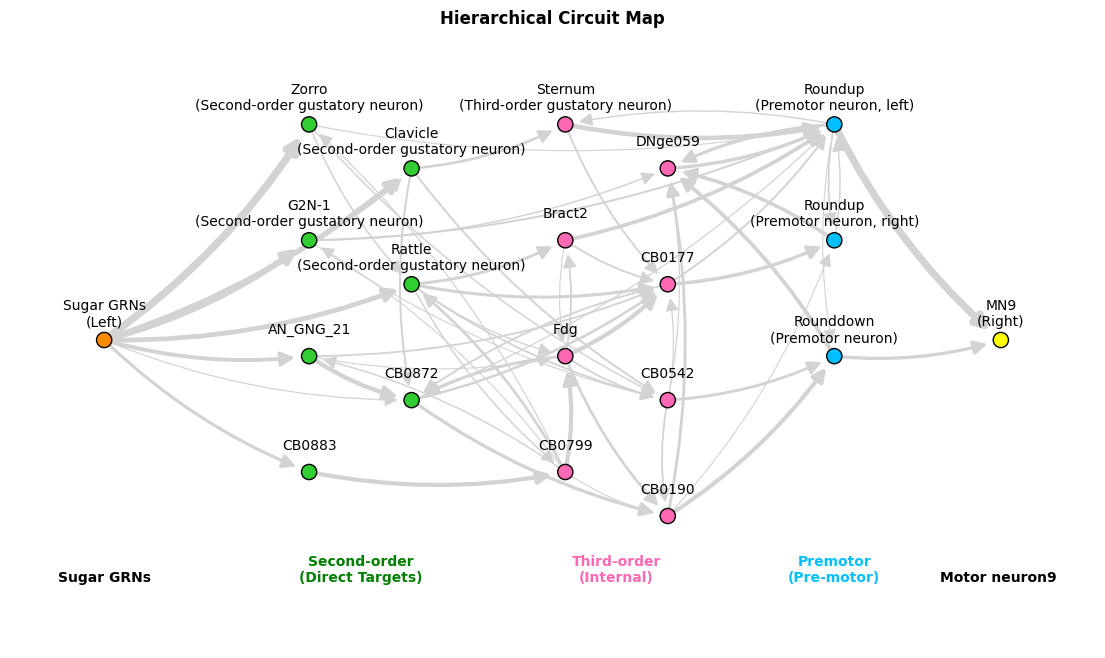

In [216]:
import networkx as nx

# --- 1. define nodes and maps ---
inter_ids = list(circuit_neurons) 
input_ids = list(NEU_SUGAR_LEFT)
output_ids = list(NEU_MN9_RIGHT)

node_labels = df_rate_sn_neurons['neuron_name'].to_dict()
node_labels.update({nid: "Sugar GRNs(Left)" for nid in input_ids})
node_labels.update({nid: "MN9 (Right)" for nid in output_ids})

all_relevant_ids = inter_ids + input_ids + output_ids

# --- 2. filter by connectome ---
df_conn = DATA['df_conn']
pre_col = DATA['columns']['pre_col']
post_col = DATA['columns']['post_col']
weight_col = DATA['columns']['weight_col']

mask = (df_conn[pre_col].isin(all_relevant_ids)) & (df_conn[post_col].isin(all_relevant_ids))
df_total = df_conn[mask].copy()

def map_to_group(nid):
    if nid in input_ids: return "Sugar GRNs (Left)"
    if nid in output_ids: return "MN9 (Right)"
    return node_labels.get(nid, str(nid))

df_total['pre_group'] = df_total[pre_col].map(map_to_group)
df_total['post_group'] = df_total[post_col].map(map_to_group)

df_grouped_conn = df_total.groupby(['pre_group', 'post_group', 'neuron_sign'])[weight_col].sum().reset_index()

# --- 3. Digraph set ---
G = nx.DiGraph()
MIN_WEIGHT = 10

for _, row in df_grouped_conn.iterrows():
    #filter weight
    if row[weight_col] < MIN_WEIGHT: continue
    if row['pre_group'] == row['post_group']: continue
    
    G.add_edge(row['pre_group'], row['post_group'], 
               weight=row[weight_col], 
               sign=row['neuron_sign'])

# --- 4. hierarchical set ---
direct_from_input = set(df_grouped_conn[df_grouped_conn['pre_group'] == "Sugar GRNs (Left)"]['post_group'])
direct_to_output = set(df_grouped_conn[df_grouped_conn['post_group'] == "MN9 (Right)"]['pre_group'])
inter_names = [node_labels[nid] for nid in inter_ids]

level_1 = [n for n in inter_names if n in direct_from_input and n not in direct_to_output]
level_3 = [n for n in inter_names if n in direct_to_output and n not in direct_from_input]
level_2 = [n for n in inter_names if (n in direct_from_input and n in direct_to_output) or (n not in direct_from_input and n not in direct_to_output)]

if 'Roundup (Premotor neuron, right)' in level_2:
    level_3.append('Roundup (Premotor neuron, right)')
    level_2.remove('Roundup (Premotor neuron, right)')

#adjust order to original paper(optional)
level_1 = ['Zorro (Second-order gustatory neuron)',
 'G2N-1 (Second-order gustatory neuron)',
 'AN_GNG_21',
 'CB0883',   
 'Clavicle (Second-order gustatory neuron)',
 'Rattle (Second-order gustatory neuron)',
 'CB0872' ]

level_2 = ['Sternum (Third-order gustatory neuron)',
 'Bract2',
 'Fdg',
 'CB0799',
 'DNge059',
 'CB0177',
 'CB0542',
 'CB0190',]

level_3 = ['Roundup (Premotor neuron, left)',
 'Roundup (Premotor neuron, right)',
 'Rounddown (Premotor neuron)']


# --- 5. coordinate of nodes---
pos = {}
pos["Sugar GRNs (Left)"] = np.array([0, 0.5])
pos["MN9 (Right)"] = np.array([7, 0.5]) # 拉开总间距

def assign_column_grid_y(nodes, x_start):
    n = len(nodes)
    if n == 0: return
    max_per_col = 4
    num_cols = (n + max_per_col - 1) // max_per_col
    col_spacing = 0.8

    stagger_offset = 0.1

    for i, node in enumerate(nodes):
        col_idx = i // max_per_col
        row_idx = i % max_per_col
        x_offset = col_idx * col_spacing - (num_cols - 1) * col_spacing / 2
        curr_x = x_start + x_offset
        y_coords = np.linspace(0.99, 0.2, max_per_col) 
        curr_y = y_coords[row_idx]

        if col_idx % 2 != 0:
            curr_y -= stagger_offset
            
        pos[node] = np.array([curr_x, curr_y])

assign_column_grid_y(level_1, 2) 
assign_column_grid_y(level_2, 4) 
assign_column_grid_y(level_3, 5.7) 

# --- 6. draw ---
plt.figure(figsize=(14, 8))

# nodes set
NODE_SIZE = 120
node_colors = []
for node in G.nodes:
    if node == "Sugar GRNs (Left)": node_colors.append('darkorange')
    elif node == "MN9 (Right)": node_colors.append('yellow')
    elif node in level_1: node_colors.append('#32CD32')
    elif node in level_3: node_colors.append('deepskyblue')
    else: node_colors.append('hotpink')

# nodes
nx.draw_networkx_nodes(G, pos, node_size=NODE_SIZE, node_color=node_colors, 
                       edgecolors='black', linewidths=1.0, alpha=1.0)

# label
LABEL_OFFSET = 0.06 # 调节这个值来控制文字离圆点的距离"
pos_labels = {node: (coords[0], coords[1] + LABEL_OFFSET) for node, coords in pos.items()}
labels = {n: n.replace(' (', '\n(') for n in G.nodes}
nx.draw_networkx_labels(G, pos_labels, labels=labels, font_size=10)

# edges
edges_exc = [(u, v) for u, v, d in G.edges(data=True) if d['sign'] == 1]

#draw connection map
nx.draw_networkx_edges(G, pos, edgelist=edges_exc, 
                       width=[np.sqrt(G[u][v]['weight'])*0.25 for u, v in edges_exc],
                       edge_color='#D3D3D3', arrowstyle='-|>', arrowsize=20,
                       node_size=NODE_SIZE, 
                       min_source_margin=5, # 增加缩进，防止起点入圈
                       min_target_margin=10, # 增加缩进，防止箭头入圈
                       connectionstyle="arc3,rad=0.1", alpha=1.0)

# supp label
plt.text(0, -0.05, "Sugar GRNs", ha='center', fontsize=10, fontweight='bold')
plt.text(2, -0.05, "Second-order\n(Direct Targets)", ha='center', fontsize=10, color='green', fontweight='bold')
plt.text(4, -0.05, "Third-order\n(Internal)", ha='center', fontsize=10, color='hotpink', fontweight='bold')
plt.text(5.7, -0.05, "Premotor\n(Pre-motor)", ha='center', fontsize=10, color='deepskyblue', fontweight='bold')
plt.text(7, -0.05, "Motor neuron9 ", ha='center', fontsize=10, fontweight='bold')

plt.title(f"Hierarchical Circuit Map", fontsize=12, fontweight='bold')
plt.axis('off')
plt.ylim(-0.2, 1.2)
plt.savefig(FIGURES_DIR/ 'fig4_Hierarchical Circuit Map.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.5 Response curves for top critical neurons

In [ ]:
# ========== 10.4 Response curves for top critical neurons (non-GRNs) ==========

print("\nFigure 4: Top 10 most critical neurons (non-GRNs)")

# Find neurons with strongest silencing effect (averaged across frequencies)
# Exclude Sugar GRNs
avg_relative = {}
for nid in top_200_neurons:
    # Skip Sugar GRNs
    if nid in NEU_SUGAR_LEFT:
        continue
    
    rates = []
    for freq in FREQ_LIST_FULL:
        if nid in results_exp3_full[freq]['silencing']:
            val = results_exp3_full[freq]['silencing'][nid]['relative_%']
            if val < 500:  # Filter outliers
                rates.append(val)
    
    if rates:
        avg_relative[nid] = {
            'avg': np.mean(rates),
            'min': np.min(rates),
            'max': np.max(rates),
        }

# Get top 10 most critical (lowest relative %, excluding GRNs)
top_10_critical = sorted(avg_relative.items(), key=lambda x: x[1]['avg'])[:10]

print(f"\nTop 10 critical non-GRN neurons:")
for i, (nid, stats) in enumerate(top_10_critical, 1):
    print(f"  {i:2d}. {nid}: avg {stats['avg']:.1f}%")

# Plot response curves
fig, ax = plt.subplots(figsize=(10, 6))

for i, (nid, stats_summary) in enumerate(top_10_critical):
    rates = [results_exp3_full[freq]['silencing'][nid]['relative_%'] 
             for freq in FREQ_LIST_FULL]
    stds = [results_exp3_full[freq]['silencing'][nid]['std'] 
            for freq in FREQ_LIST_FULL]
    
    # Convert std to relative % std (approximate)
    rel_stds = [s / results_exp3_full[freq]['control']['mean'] * 100 
                for freq, s in zip(FREQ_LIST_FULL, stds)]
    
    ax.errorbar(FREQ_LIST_FULL, rates, yerr=rel_stds,
                marker='o', markersize=6, capsize=4, linewidth=1.5, alpha=0.7,
                label=f'Top {i+1} (avg {stats_summary["avg"]:.0f}%)')

# Reference lines
ax.axhline(y=100, color='red', linestyle='-', linewidth=2, label='Control', alpha=0.7)
ax.axhline(y=NECESSITY_THRESHOLD, color='orange', linestyle='--', linewidth=1.5,
           label=f'Threshold ({NECESSITY_THRESHOLD}%)', alpha=0.7)

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('Relative MN9 Firing Rate (%)', fontsize=12)
ax.set_title('Top 10 Most Critical Non-GRN Neurons', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig((FIGURES_DIR / 'fig5_top10_critical_curves_nonGRNs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: fig5_top10_critical_curves_nonGRNs.png")

## 9. Save Complete Results

In [ ]:
print("\n" + "=" * 70)
print("Saving Complete Results")
print("=" * 70)

# Save necessary neurons (for future use)
necessary_neurons_array = np.array(list(necessary_any))
np.save(RESULTS_DIR  / 'necessary_neurons.npy', necessary_neurons_array)

print(f"\n✅ Saved necessary neurons:")
print(f"  {RESULTS_DIR  / 'necessary_neurons.npy'}")
print(f"  Count: {len(necessary_neurons_array)}")

# Save complete results package
results_package = {
    'results': results_exp3_full,
    'neurons_silenced': top_200_neurons,
    'freq_list': FREQ_LIST_FULL,
    'necessary_neurons': {
        'by_frequency': necessary_by_freq,
        'any_frequency': list(necessary_any),
        'threshold': NECESSITY_THRESHOLD,
    },
    'parameters': {
        'n_trials': N_TRIALS,
        'n_workers': N_WORKERS,
        'sugar_grn_ids': NEU_SUGAR_LEFT,
        'mn9_id': NEU_MN9_RIGHT[0],
    },
    'metadata': {
        'date': pd.Timestamp.now().isoformat(),
        'connectome_version': 783,
    }
}

with open(RESULTS_DIR  / 'exp3_complete_results.pkl', 'wb') as f:
    pickle.dump(results_package, f)

print(f"\n✅ Complete package saved:")
print(f"  {RESULTS_DIR  / 'exp3_complete_results.pkl'}")

# Save summary CSV
summary_data = []
for freq in FREQ_LIST_FULL:
    ctrl = results_exp3_full[freq]['control']
    silencing = results_exp3_full[freq]['silencing']
    
    relative_pcts = [s['relative_%'] for s in silencing.values() if s['relative_%'] < 500]
    n_necessary = sum(1 for r in relative_pcts if r < NECESSITY_THRESHOLD)
    
    summary_data.append({
        'Frequency': freq,
        'Control_Mean': ctrl['mean'],
        'Control_Std': ctrl['std'],
        'Necessary_Neurons': n_necessary,
        'Percent_Necessary': f"{100*n_necessary/200:.1f}%",
        'Min_Relative%': min(relative_pcts),
        'Max_Relative%': max(relative_pcts),
        'Mean_Relative%': np.mean(relative_pcts),
    })

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv(RESULTS_DIR  / 'summary.csv', index=False)

print(f"  {RESULTS_DIR  / 'summary.csv'}")

# Save silencing matrix (neurons × frequencies)
silencing_matrix = pd.DataFrame(
    index=top_200_neurons,
    columns=FREQ_LIST_FULL
)

for freq in FREQ_LIST_FULL:
    for nid in top_200_neurons:
        if nid in results_exp3_full[freq]['silencing']:
            silencing_matrix.loc[nid, freq] = results_exp3_full[freq]['silencing'][nid]['relative_%']

silencing_matrix.to_csv(RESULTS_DIR  / 'silencing_matrix.csv')
print(f"  {FIGURES_DIR/ 'silencing_matrix.csv'}")
print(f"    (200 neurons × 8 frequencies, values in relative %)")

## 10. Experiment Summary

In [ ]:
print("\n" + "=" * 70)
print("✅ Experiment 3 Complete!")
print("=" * 70)

print(f"\n[Summary Table]")
print(df_summary.to_string(index=False))

print(f"\n[Key Findings]")
print(f"  Neurons tested: {len(top_200_neurons)}")
print(f"  Frequencies tested: {len(FREQ_LIST_FULL)}")
print(f"  Total conditions: {len(top_200_neurons) * len(FREQ_LIST_FULL)}")
print(f"  Necessary at ANY frequency: {len(necessary_any)} neurons")

# Most critical frequency
max_necessary_freq = max(necessary_by_freq.items(), key=lambda x: len(x[1]))
print(f"  Most critical frequency: {max_necessary_freq[0]} Hz ({len(max_necessary_freq[1])} necessary neurons)")

print(f"\n[Outputs]")
print(f"  Results directory: {RESULTS_DIR }/")
print(f"  - exp3_complete_results.pkl (full data)")
print(f"  - necessary_neurons.npy (for Venn/analysis)")
print(f"  - summary.csv (table)")
print(f"  - silencing_matrix.csv (200 neurons × 8 frequencies)")
print(f"  - figures/ (5 plots)")

print(f"\n[Next Steps]")
print(f"  1. Compare with Exp2 results (Venn diagram)")
print(f"  2. Analyze critical neuron types (using classification data)")
print(f"  3. Compare with original paper Figure 1f-h")

print("\n" + "=" * 70)

---

## Appendix: Detailed Analysis

### A1. Frequency-dependent necessity

In [ ]:
# Plot: Number of necessary neurons vs frequency
fig, ax = plt.subplots(figsize=(6, 6))

freqs = sorted(necessary_by_freq.keys())
counts = [len(necessary_by_freq[f]) for f in freqs]

bars = ax.bar(range(len(freqs)), counts, color='coral', 
              edgecolor='black', alpha=0.8)

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('Number of Necessary Neurons', fontsize=12)
ax.set_title('Frequency Dependence of Necessity', fontsize=13, fontweight='bold')

ax.set_xticks(range(len(freqs)))
ax.set_xticklabels(freqs)

# Add value labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=10)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'appendix_necessity_vs_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNecessary neurons per frequency:")
for freq, count in zip(freqs, counts):
    print(f"  {freq:3d} Hz: {count:3d} neurons ({100*count/200:.1f}%)")

### A2. Distribution of silencing effects

In [ ]:
# Multi-panel histogram for all frequencies
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, freq in zip(axes, FREQ_LIST_FULL):
    silencing = results_exp3_full[freq]['silencing']
    
    relative_rates = [s['relative_%'] for s in silencing.values() 
                     if s['relative_%'] < 500]
    
    bins = np.arange(0, 210, 10)
    counts, edges, patches = ax.hist(relative_rates, bins=bins,
                                      edgecolor='black', alpha=0.7, color='steelblue')
    
    # Color critical neurons
    for i, patch in enumerate(patches):
        if edges[i] < NECESSITY_THRESHOLD:
            patch.set_facecolor('coral')
    
    ax.axvline(x=100, color='red', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.axvline(x=NECESSITY_THRESHOLD, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.set_xlabel('Relative %', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{freq} Hz', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add count
    n_req = sum(1 for r in relative_rates if r < NECESSITY_THRESHOLD)
    ax.text(0.98, 0.98, f'{n_req}/200', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Silencing Effect Distribution Across Frequencies', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'appendix_all_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: appendix_all_histograms.png")

### A3. Control firing rates across frequencies

In [ ]:
# Plot control MN9 firing rates
fig, ax = plt.subplots(figsize=(10, 6))

control_means = [results_exp3_full[freq]['control']['mean'] for freq in FREQ_LIST_FULL]
control_stds = [results_exp3_full[freq]['control']['std'] for freq in FREQ_LIST_FULL]

ax.errorbar(FREQ_LIST_FULL, control_means, yerr=control_stds,
            marker='o', markersize=8, capsize=5, capthick=2,
            linewidth=2, color='steelblue', label='MN9 (no silencing)')

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('MN9 Firing Rate (Hz)', fontsize=12)
ax.set_title('Control MN9 Response (No Silencing)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add trend line
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(FREQ_LIST_FULL, control_means)
trend_line = [slope * f + intercept for f in FREQ_LIST_FULL]
ax.plot(FREQ_LIST_FULL, trend_line, 'r--', alpha=0.5, linewidth=1.5,
        label=f'Trend (r²={r_value**2:.3f})')
ax.legend(fontsize=10)

plt.tight_layout()
# plt.savefig(FIGURES_DIR / 'appendix_control_response.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: appendix_control_response.png")
print(f"\n  Control MN9 response:")
for freq, mean, std in zip(FREQ_LIST_FULL, control_means, control_stds):
    print(f"    {freq:3d} Hz: {mean:5.1f} ± {std:4.1f} Hz")